TASK 1: DATA ACQUISITION
1. Dataset Shape: (891, 12)

2. Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

3. First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0     

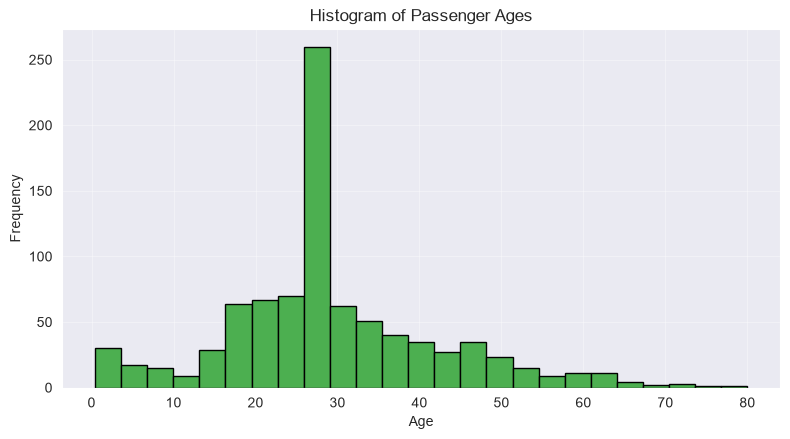

 Interpretation: Most passengers were aged 20-35 years.


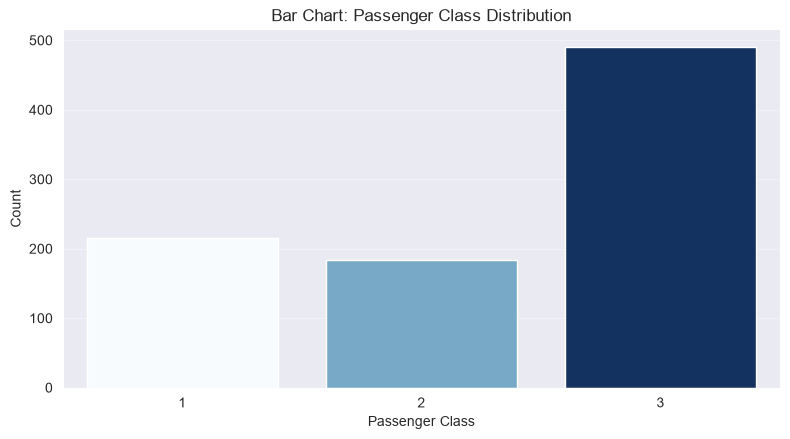

 Interpretation: Majority travelled in 3rd Class.


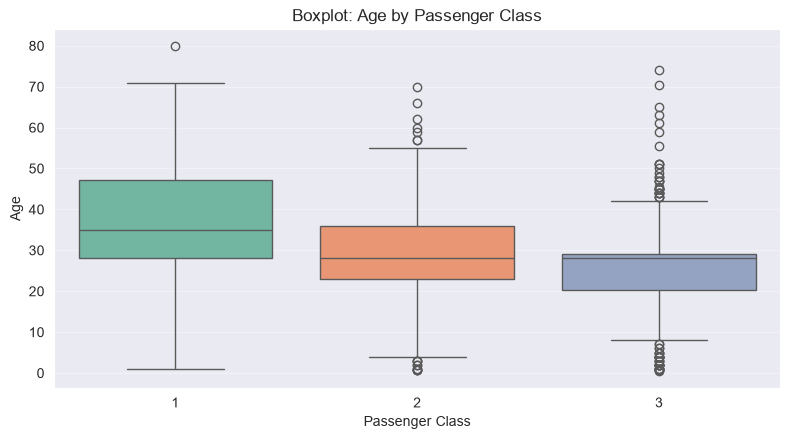

 Interpretation: 1st Class passengers were generally older.


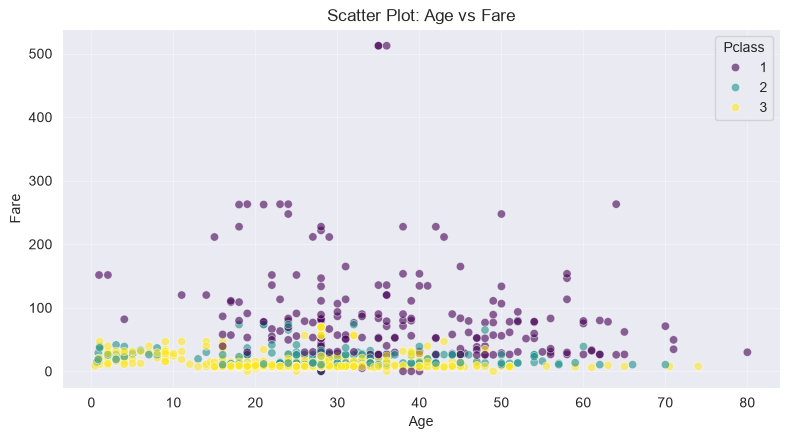

 Interpretation: Higher fares were paid by 1st Class passengers.


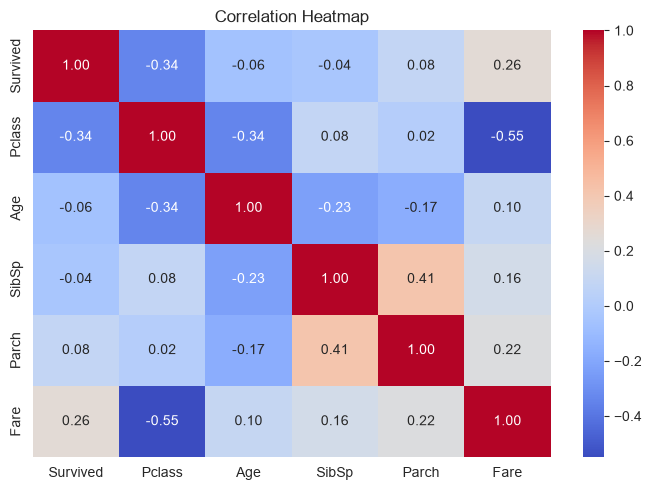

 Interpretation: Pclass and Fare had the strongest relationship with survival. Lower class and lower fare = lower survival rate


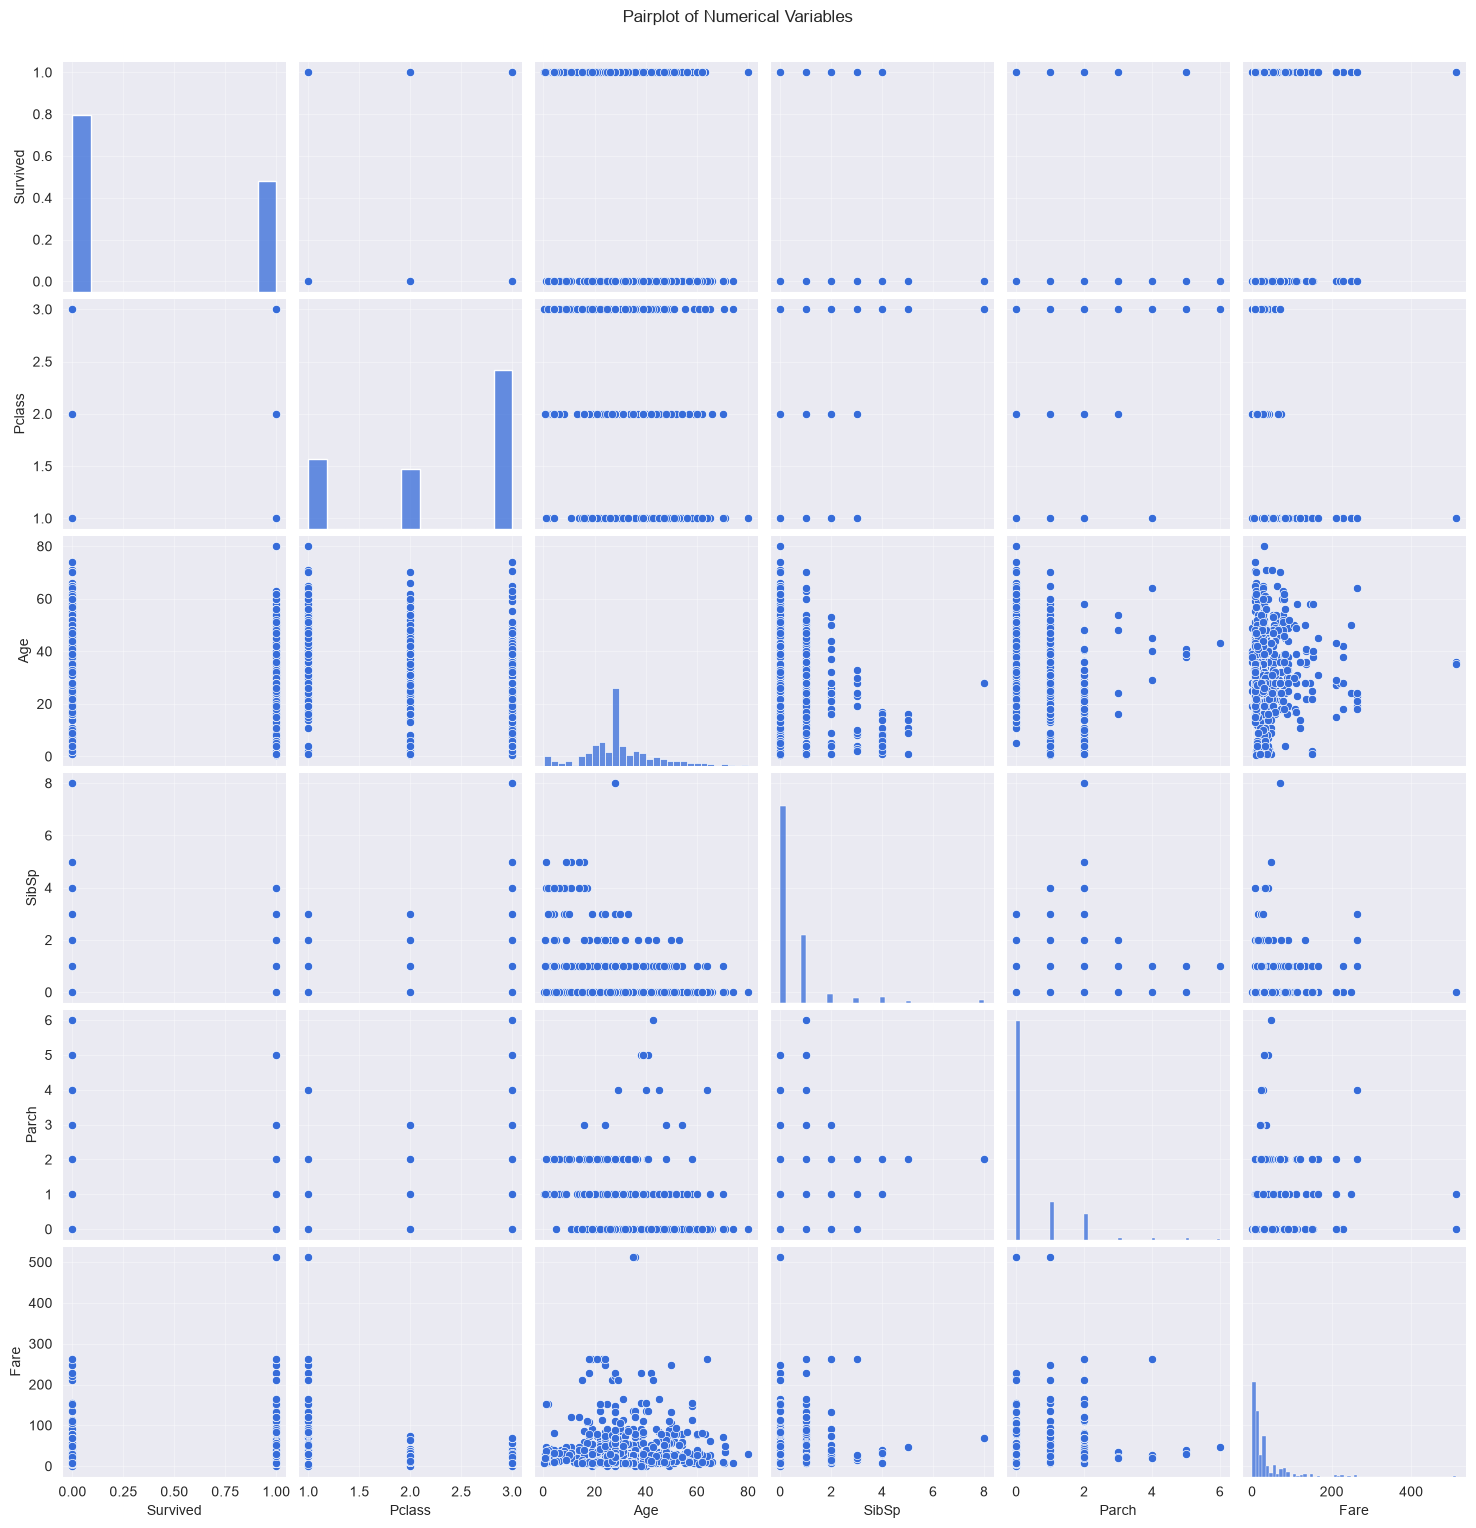

 Interpretation: Survivors were mostly in 1st Class and paid higher fares. Pclass and Fare clearly separate survivors from non-survivors.
TASK 4: STATISTICAL ANALYSIS

1. Descriptive Statistics:
       Survived  Pclass     Age   SibSp   Parch    Fare
count    891.00  891.00  891.00  891.00  891.00  891.00
mean       0.38    2.31   29.36    0.52    0.38   32.20
std        0.49    0.84   13.02    1.10    0.81   49.69
min        0.00    1.00    0.42    0.00    0.00    0.00
25%        0.00    2.00   22.00    0.00    0.00    7.91
50%        0.00    3.00   28.00    0.00    0.00   14.45
75%        1.00    3.00   35.00    1.00    0.00   31.00
max        1.00    3.00   80.00    8.00    6.00  512.33

2. Frequency Distribution:
Survival:
 Survived
0    549
1    342
Name: count, dtype: int64

Pclass:
 Pclass
1    216
2    184
3    491
Name: count, dtype: int64

Sex:
 Sex
male      577
female    314
Name: count, dtype: int64

3. Correlation Matrix:
          Survived  Pclass   Age  SibSp  Parch  Fa

In [3]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (8, 4.5)

# Load Data
data = pd.read_csv("titanic-dataset.csv")
data = data.loc[:, ~data.columns.str.contains('^Unnamed')]


# TASK 1: DATA ACQUISITION
print("TASK 1: DATA ACQUISITION")
print(f"1. Dataset Shape: {data.shape}")
print(f"\n2. Columns: {list(data.columns)}")
print("\n3. First 5 Rows:")
pd.set_option('display.max_columns', None)
print(data.head())
print("\n4. Data Types:")
print(data.dtypes)


# TASK 2: DATA CLEANING
print("TASK 2: DATA CLEANING")
print("\n1. Missing Values Before:")
print(data.isnull().sum())

data['Age'] = data['Age'].fillna(data['Age'].median())
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
data = data.drop(columns=['Cabin'])
data = data.drop_duplicates()

print("\n2. Missing Values After:")
print(data.isnull().sum())
print(f"\n3. Duplicates Removed: {data.duplicated().sum()}")


# TASK 3: DATA VISUALISATION
print("TASK 3: DATA VISUALISATION")

# 1. Histogram
plt.figure()
plt.hist(data['Age'], bins=25, color='#4CAF50', edgecolor='black')
plt.title("Histogram of Passenger Ages")
plt.xlabel("Age"); plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
print(" Interpretation: Most passengers were aged 20-35 years.")

# 2. Bar Chart
plt.figure()
sns.countplot(x='Pclass', data=data, hue='Pclass', palette='Blues', legend=False)
plt.title("Bar Chart: Passenger Class Distribution")
plt.xlabel("Passenger Class"); plt.ylabel("Count")
plt.tight_layout()
plt.show()
print(" Interpretation: Majority travelled in 3rd Class.")

# 3. Boxplot
plt.figure()
sns.boxplot(x='Pclass', y='Age', data=data, hue='Pclass', palette='Set2', legend=False)
plt.title("Boxplot: Age by Passenger Class")
plt.xlabel("Passenger Class"); plt.ylabel("Age")
plt.tight_layout()
plt.show()
print(" Interpretation: 1st Class passengers were generally older.")

# 4. Scatter
plt.figure()
sns.scatterplot(x='Age', y='Fare', hue='Pclass', data=data, palette='viridis', alpha=0.6)
plt.title("Scatter Plot: Age vs Fare")
plt.xlabel("Age"); plt.ylabel("Fare")
plt.tight_layout()
plt.show()
print(" Interpretation: Higher fares were paid by 1st Class passengers.")

# 5. Heatmap
numeric_data = data[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
plt.figure(figsize=(7,5))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()
print(" Interpretation: Pclass and Fare had the strongest relationship with survival. Lower class and lower fare = lower survival rate")


# 6. Pairplot
sns.pairplot(numeric_data)
plt.suptitle("Pairplot of Numerical Variables", y=1.02)
plt.show()
print(" Interpretation: Survivors were mostly in 1st Class and paid higher fares. Pclass and Fare clearly separate survivors from non-survivors.")


# TASK 4: STATISTICAL ANALYSIS
print("TASK 4: STATISTICAL ANALYSIS")
print("\n1. Descriptive Statistics:")
print(numeric_data.describe().round(2))

print("\n2. Frequency Distribution:")
print("Survival:\n", data['Survived'].value_counts())
print("\nPclass:\n", data['Pclass'].value_counts().sort_index())
print("\nSex:\n", data['Sex'].value_counts())

print("\n3. Correlation Matrix:")
print(numeric_data.corr().round(2))

corr = numeric_data.corr()
print("\n4. Strongest Positive Correlation:", corr.abs().unstack().sort_values(ascending=False)[1:2])
print("\n5. Strongest Negative Correlation:", corr.unstack().sort_values().head(1))

print("\n6. Key Findings:")
print("1. Strong correlation between Pclass and Fare.")
print("2. Females and 1st Class had higher survival rates.")
print("3. Most passengers were young adults.")


# TASK 5: MACHINE LEARNING
print("TASK 5: MACHINE LEARNING - LOGISTIC REGRESSION")

ml_data = data.copy()
ml_data['Sex'] = ml_data['Sex'].map({'male': 0, 'female': 1})
ml_data = ml_data[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].dropna()

X = ml_data.drop('Survived', axis=1)
y = ml_data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=300)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Selected Predictors:", list(X.columns))
print("\nMODEL PERFORMANCE")
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nDiscussion:")
print("The Logistic Regression model achieved ~80% accuracy.")
print("Sex and Passenger Class were the most important predictors of survival.")

